# FIFA Player Selection Analysis — Budget-Constrained Youth Squad Builder

Bu projede FIFA oyuncu verileri kullanılarak sınırlı bütçeyle genç, potansiyelli ve dengeli bir futbol kadrosu oluşturulmuştur.
Amaç, €100M transfer bütçesi ve €600K haftalık maaş limiti altında 15 kişilik bir takım kurmaktır.

## Problem Statement

Yeni kurulacak bir futbol kulübü için 15 kişilik kadro seçilmesi hedeflenmiştir.

Kadro yapısı:

- 11 Starting XI oyuncusu
- 4 yedek oyuncu
- 1 GK, 4 DEF, 3 MID, 3 ATK
- Yedekler: 1 GK, 1 DEF, 1 MID, 1 ATK

Kısıtlar:

- Toplam transfer bütçesi: €100M
- Toplam haftalık maaş limiti: €600K
- Genç ve gelişebilir oyunculara öncelik verilmiştir

## Dataset

Kullanılan veri seti FIFA oyuncu istatistiklerini içermektedir.

Veri setinde oyuncuların:

- Yaş
- Pozisyon
- Kulüp
- Overall rating
- Potential rating
- Market değeri
- Haftalık maaşı
- Teknik özellikleri

gibi bilgiler bulunmaktadır.

## Methodology

Bu proje klasik bir machine learning modeli değildir.

Burada rule-based recommendation sistemi kurulmuştur.

Oyuncular şu kriterlere göre değerlendirilmiştir:

- Overall rating
- Potential rating
- Yaş
- Transfer değeri
- Haftalık maaş
- Pozisyon ihtiyacı
- Bütçe limiti

Sistem önce oyuncuları pozisyon gruplarına ayırır:

- GK
- DEF
- MID
- ATK

Daha sonra her oyuncu için bir skor hesaplar ve bütçe sınırları içinde kadro kurar.

In [1]:
import pandas as pd
df = pd.read_csv("data/fifa_eda_stats.csv")
df.head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,€110.5M,€565K,Left,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,€77M,€405K,Right,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,€118.5M,€290K,Right,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,193080,De Gea,27,Spain,91,93,Manchester United,€72M,€260K,Right,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,€102M,€355K,Right,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


In [2]:
df.shape
df.columns
df.isnull().sum()

ID                              0
Name                            0
Age                             0
Nationality                     0
Overall                         0
Potential                       0
Club                          241
Value                           0
Wage                            0
Preferred Foot                 48
International Reputation       48
Weak Foot                      48
Skill Moves                    48
Work Rate                      48
Body Type                      48
Position                       60
Jersey Number                  60
Joined                       1553
Loaned From                 16943
Contract Valid Until          289
Height                         48
Weight                         48
Crossing                       48
Finishing                      48
HeadingAccuracy                48
ShortPassing                   48
Volleys                        48
Dribbling                      48
Curve                          48
FKAccuracy    

In [3]:
def money_to_number(x):
    x = str(x).replace('€', '').replace('�', '').strip()
    if x.endswith('M'):
        return float(x[:-1]) * 1_000_000
    elif x.endswith('K'):
        return float(x[:-1]) * 1_000
    return float(x) if x else 0

df["Value_Num"] = df["Value"].apply(money_to_number)
df["Wage_Num"] = df["Wage"].apply(money_to_number)

df[["Name", "Value", "Value_Num", "Wage", "Wage_Num"]].head(10)

,Name,Value,Value_Num,Wage,Wage_Num
0,L. Messi,€110.5M,110500000.0,€565K,565000.0
1,Cristiano Ronaldo,€77M,77000000.0,€405K,405000.0
2,Neymar Jr,€118.5M,118500000.0,€290K,290000.0
3,De Gea,€72M,72000000.0,€260K,260000.0
4,K. De Bruyne,€102M,102000000.0,€355K,355000.0
5,E. Hazard,€93M,93000000.0,€340K,340000.0
6,L. Modrić,€67M,67000000.0,€420K,420000.0
7,L. Suárez,€80M,80000000.0,€455K,455000.0
8,Sergio Ramos,€51M,51000000.0,€380K,380000.0
9,J. Oblak,€68M,68000000.0,€94K,94000.0


In [4]:
players = df.copy()

In [5]:
# STEP 2 — Oyuncu temizleme + pozisyon gruplama

gk_positions = ["GK"]

def_positions = ["CB", "LCB", "RCB", "LB", "RB", "LWB", "RWB"]

mid_positions = [
    "CM", "LCM", "RCM", "CDM", "LDM", "RDM",
    "CAM", "LAM", "RAM", "LM", "RM"
]

atk_positions = ["ST", "LS", "RS", "CF", "LF", "RF", "LW", "RW"]

def position_group(pos):
    if pos in gk_positions:
        return "GK"
    elif pos in def_positions:
        return "DEF"
    elif pos in mid_positions:
        return "MID"
    elif pos in atk_positions:
        return "ATK"
    else:
        return "OTHER"

players["Group"] = players["Position"].apply(position_group)

players = players[
    (players["Value_Num"] > 0) &
    (players["Wage_Num"] > 0) &
    (players["Position"].notna()) &
    (players["Group"] != "OTHER") &
    (players["Age"] >= 18) &
    (players["Age"] <= 35) &
    (players["Potential"] >= 80)
].copy()

players["ValueM"] = players["Value_Num"] / 1_000_000
players["WageK"] = players["Wage_Num"] / 1_000

players[[
    "Name", "Age", "Position", "Group", "Overall", "Potential", 
    "Value", "Wage", "ValueM", "WageK"
]].head(20)

,Name,Age,Position,Group,Overall,Potential,Value,Wage,ValueM,WageK
0,L. Messi,31,RF,ATK,94,94,€110.5M,€565K,110.5,565.0
1,Cristiano Ronaldo,33,ST,ATK,94,94,€77M,€405K,77.0,405.0
2,Neymar Jr,26,LW,ATK,92,93,€118.5M,€290K,118.5,290.0
3,De Gea,27,GK,GK,91,93,€72M,€260K,72.0,260.0
4,K. De Bruyne,27,RCM,MID,91,92,€102M,€355K,102.0,355.0
5,E. Hazard,27,LF,ATK,91,91,€93M,€340K,93.0,340.0
6,L. Modrić,32,RCM,MID,91,91,€67M,€420K,67.0,420.0
7,L. Suárez,31,RS,ATK,91,91,€80M,€455K,80.0,455.0
8,Sergio Ramos,32,RCB,DEF,91,91,€51M,€380K,51.0,380.0
9,J. Oblak,25,GK,GK,90,93,€68M,€94K,68.0,94.0


## V5 Result — Budget Aware Squad Builder

This version successfully creates a 15-player squad under the €100M transfer budget.
However, some Starting XI players have low current overall ratings, which shows that the model is too potential-focused.
Next step: improve the model by enforcing a higher minimum Overall for Starting XI players.

In [6]:
# FINAL ENGINE V6 — Balanced Squad Builder
# Amaç:
# - 15 kişilik takım
# - €100M bütçe altında
# - Starting XI daha kaliteli
# - Bench daha esnek
# - Genç + potansiyelli + makul fiyatlı kadro

BUDGET_M = 100
WAGE_LIMIT_K = 600

players = df.copy()

# 1) Pozisyon grupları
gk_positions = ["GK"]
def_positions = ["CB", "LCB", "RCB", "LB", "RB", "LWB", "RWB"]
mid_positions = ["CM", "LCM", "RCM", "CDM", "LDM", "RDM", "CAM", "LAM", "RAM", "LM", "RM"]
atk_positions = ["ST", "LS", "RS", "CF", "LF", "RF", "LW", "RW"]

def position_group(pos):
    if pos in gk_positions:
        return "GK"
    elif pos in def_positions:
        return "DEF"
    elif pos in mid_positions:
        return "MID"
    elif pos in atk_positions:
        return "ATK"
    return "OTHER"

players["Group"] = players["Position"].apply(position_group)

# 2) Temel veri filtresi
players = players[
    (players["Value_Num"] > 0) &
    (players["Wage_Num"] > 0) &
    (players["Group"] != "OTHER") &
    (players["Age"] >= 18) &
    (players["Age"] <= 30)
].copy()

players["ValueM"] = players["Value_Num"] / 1_000_000
players["WageK"] = players["Wage_Num"] / 1_000

# 3) Base score
players["Base_Score"] = (
    (players["Overall"] ** 2.10) * 0.50 +
    (players["Potential"] ** 2.35) * 0.50 +
    ((28 - players["Age"]).clip(lower=-5) * 80)
    - (players["ValueM"] * 55)
    - (players["WageK"] * 5)
)

selected = []
selected_ids = set()
remaining_budget = BUDGET_M
remaining_wage = WAGE_LIMIT_K

final_needs = {
    ("Starting XI", "GK"): 1,
    ("Starting XI", "DEF"): 4,
    ("Starting XI", "MID"): 3,
    ("Starting XI", "ATK"): 3,
    ("Bench", "GK"): 1,
    ("Bench", "DEF"): 1,
    ("Bench", "MID"): 1,
    ("Bench", "ATK"): 1,
}

def count_selected(role, group):
    return sum(1 for p in selected if p["Squad_Role"] == role and p["Group"] == group)

def total_remaining_slots():
    remaining = 0
    for (role, group), needed in final_needs.items():
        remaining += max(0, needed - count_selected(role, group))
    return remaining

def pick_player(group, role, tiers):
    global remaining_budget, remaining_wage

    slots_left = total_remaining_slots()
    if slots_left <= 0:
        return False

    # Kalan slotlar için minimum para ayır
    min_future_budget = 1.0
    min_future_wage = 4

    reserve_budget = max(0, (slots_left - 1) * min_future_budget)
    reserve_wage = max(0, (slots_left - 1) * min_future_wage)

    max_affordable_value = max(0, remaining_budget - reserve_budget)
    max_affordable_wage = max(0, remaining_wage - reserve_wage)

    for tier in tiers:
        pool = players[
            (players["Group"] == group) &
            (~players["ID"].isin(selected_ids)) &
            (players["Overall"] >= tier["min_overall"]) &
            (players["Potential"] >= tier["min_potential"]) &
            (players["Age"] <= tier["max_age"]) &
            (players["ValueM"] <= max_affordable_value * tier["budget_share"]) &
            (players["WageK"] <= max_affordable_wage * tier["wage_share"])
        ].copy()

        if len(pool) == 0:
            continue

        # Role göre puanlama
        if role == "Starting XI":
            pool["Pick_Score"] = (
                pool["Base_Score"]
                + (pool["Overall"] * 110)
                + (pool["Potential"] * 35)
                - (pool["ValueM"] * tier["value_penalty"])
                - (pool["WageK"] * tier["wage_penalty"])
            )
        else:
            pool["Pick_Score"] = (
                pool["Base_Score"]
                + (pool["Potential"] * 70)
                - (pool["ValueM"] * tier["value_penalty"])
                - (pool["WageK"] * tier["wage_penalty"])
            )

        best = pool.sort_values("Pick_Score", ascending=False).iloc[0]

        selected.append({
            "Squad_Role": role,
            "Group": best["Group"],
            "Name": best["Name"],
            "Age": best["Age"],
            "Position": best["Position"],
            "Club": best["Club"],
            "Overall": best["Overall"],
            "Potential": best["Potential"],
            "Value": best["Value"],
            "Wage": best["Wage"],
            "ValueM": best["ValueM"],
            "WageK": best["WageK"],
            "Pick_Score": best["Pick_Score"]
        })

        selected_ids.add(best["ID"])
        remaining_budget -= best["ValueM"]
        remaining_wage -= best["WageK"]

        return True

    return False


# 4) Starting XI için daha kaliteli tier'lar
starting_premium_tiers = [
    {"min_overall": 76, "min_potential": 84, "max_age": 26, "budget_share": 0.48, "wage_share": 0.45, "value_penalty": 30, "wage_penalty": 3},
    {"min_overall": 74, "min_potential": 82, "max_age": 27, "budget_share": 0.55, "wage_share": 0.50, "value_penalty": 35, "wage_penalty": 4},
    {"min_overall": 72, "min_potential": 80, "max_age": 28, "budget_share": 0.65, "wage_share": 0.55, "value_penalty": 42, "wage_penalty": 5},
]

starting_normal_tiers = [
    {"min_overall": 72, "min_potential": 80, "max_age": 28, "budget_share": 0.40, "wage_share": 0.40, "value_penalty": 45, "wage_penalty": 5},
    {"min_overall": 70, "min_potential": 78, "max_age": 29, "budget_share": 0.50, "wage_share": 0.50, "value_penalty": 50, "wage_penalty": 6},
]

# Bench için daha esnek tier'lar
bench_tiers = [
    {"min_overall": 68, "min_potential": 76, "max_age": 29, "budget_share": 0.35, "wage_share": 0.35, "value_penalty": 55, "wage_penalty": 6},
    {"min_overall": 66, "min_potential": 74, "max_age": 30, "budget_share": 0.55, "wage_share": 0.55, "value_penalty": 60, "wage_penalty": 7},
    {"min_overall": 64, "min_potential": 72, "max_age": 30, "budget_share": 0.80, "wage_share": 0.80, "value_penalty": 65, "wage_penalty": 8},
]

# 5) Önce omurga oyuncuları
priority_plan = [
    ("ATK", "Starting XI", starting_premium_tiers),
    ("GK",  "Starting XI", starting_premium_tiers),
    ("DEF", "Starting XI", starting_premium_tiers),
    ("MID", "Starting XI", starting_premium_tiers),
    ("DEF", "Starting XI", starting_normal_tiers),
    ("MID", "Starting XI", starting_normal_tiers),
]

for group, role, tiers in priority_plan:
    pick_player(group, role, tiers)

# 6) Starting XI tamamla
starting_needs = {
    "GK": 1,
    "DEF": 4,
    "MID": 3,
    "ATK": 3
}

for group, needed in starting_needs.items():
    while count_selected("Starting XI", group) < needed:
        success = pick_player(group, "Starting XI", starting_normal_tiers)
        if not success:
            # Mecbur kalırsak biraz gevşet
            fallback_tiers = [
                {"min_overall": 68, "min_potential": 76, "max_age": 30, "budget_share": 0.70, "wage_share": 0.70, "value_penalty": 55, "wage_penalty": 7}
            ]
            success = pick_player(group, "Starting XI", fallback_tiers)
        if not success:
            break

# 7) Bench tamamla
bench_needs = {
    "GK": 1,
    "DEF": 1,
    "MID": 1,
    "ATK": 1
}

for group, needed in bench_needs.items():
    while count_selected("Bench", group) < needed:
        success = pick_player(group, "Bench", bench_tiers)
        if not success:
            break

final_squad = pd.DataFrame(selected)

print(f"Total Transfer Value: €{final_squad['ValueM'].sum():.1f}M / €{BUDGET_M}M")
print(f"Total Weekly Wage: €{final_squad['WageK'].sum():.0f}K / €{WAGE_LIMIT_K}K")
print(f"Remaining Budget: €{remaining_budget:.1f}M")
print(f"Remaining Wage: €{remaining_wage:.0f}K")
print(f"Squad Size: {len(final_squad)} players")
print(f"Remaining Slots: {total_remaining_slots()}")

final_squad[
    [
        "Squad_Role", "Group", "Name", "Age", "Position", "Club",
        "Overall", "Potential", "Value", "Wage", "ValueM", "WageK", "Pick_Score"
    ]
].sort_values(
    ["Squad_Role", "Group", "Pick_Score"],
    ascending=[False, True, False]
)

Total Transfer Value: €98.1M / €100M
Total Weekly Wage: €229K / €600K
Remaining Budget: €1.8M
Remaining Wage: €371K
Squad Size: 14 players
Remaining Slots: 1


,Squad_Role,Group,Name,Age,Position,Club,Overall,Potential,Value,Wage,ValueM,WageK,Pick_Score
0,Starting XI,ATK,Gabriel Jesus,21,ST,Manchester City,83,92,€41M,€130K,41.000,130.0,34343.584223
9,Starting XI,ATK,André Vidigal,19,LW,Fortuna Sittard,68,78,€1.4M,€2K,1.400,2.0,28253.949566
2,Starting XI,DEF,T. Alexander-Arnold,19,RB,Liverpool,78,88,€14M,€36K,14.000,36.0,34161.782821
4,Starting XI,DEF,D. Maresic,18,LCB,SK Sturm Graz,72,84,€4.5M,€6K,4.500,6.0,31760.419670
7,Starting XI,DEF,N. Cozza,19,CB,Montpellier HSC,69,85,€2M,€5K,2.000,5.0,31744.674957
6,Starting XI,DEF,T. Malacia,18,LB,Feyenoord,70,80,€2.2M,€3K,2.200,3.0,29616.017265
1,Starting XI,GK,A. Lafont,19,GK,Fiorentina,78,90,€14M,€12K,14.000,12.0,35430.131982
8,Starting XI,MID,S. Tonali,18,CDM,Brescia,68,89,€1.8M,€1K,1.800,1.0,33766.855694
3,Starting XI,MID,W. McKennie,19,LCM,FC Schalke 04,74,86,€9.5M,€12K,9.500,12.0,32698.633019
5,Starting XI,MID,J. Dilrosun,20,LM,Hertha BSC,70,86,€3.9M,€11K,3.900,11.0,32147.343232


In [7]:
# V6.1 — Emergency Filler for Missing Slots

# Eksik slotları tespit et
missing_slots = []

for (role, group), needed in final_needs.items():
    current = count_selected(role, group)
    missing = needed - current
    
    for _ in range(max(0, missing)):
        missing_slots.append((role, group))

print("Missing slots:", missing_slots)

# Eksik slotları kalan bütçe ile doldur
for role, group in missing_slots:
    
    emergency_pool = players[
        (players["Group"] == group) &
        (~players["ID"].isin(selected_ids)) &
        (players["ValueM"] <= remaining_budget) &
        (players["WageK"] <= remaining_wage) &
        (players["Age"] <= 30) &
        (players["Overall"] >= 62) &
        (players["Potential"] >= 70)
    ].copy()
    
    if len(emergency_pool) == 0:
        print(f"No available player found for {role} {group}")
        continue
    
    emergency_pool["Emergency_Score"] = (
        emergency_pool["Overall"] * 3 +
        emergency_pool["Potential"] * 2 +
        (30 - emergency_pool["Age"]) * 1.5
        - emergency_pool["ValueM"] * 15
        - emergency_pool["WageK"] * 2
    )
    
    best = emergency_pool.sort_values("Emergency_Score", ascending=False).iloc[0]
    
    selected.append({
        "Squad_Role": role,
        "Group": best["Group"],
        "Name": best["Name"],
        "Age": best["Age"],
        "Position": best["Position"],
        "Club": best["Club"],
        "Overall": best["Overall"],
        "Potential": best["Potential"],
        "Value": best["Value"],
        "Wage": best["Wage"],
        "ValueM": best["ValueM"],
        "WageK": best["WageK"],
        "Pick_Score": best["Emergency_Score"]
    })
    
    selected_ids.add(best["ID"])
    remaining_budget -= best["ValueM"]
    remaining_wage -= best["WageK"]

# Final tabloyu yeniden oluştur
final_squad = pd.DataFrame(selected)

print(f"Total Transfer Value: €{final_squad['ValueM'].sum():.1f}M / €{BUDGET_M}M")
print(f"Total Weekly Wage: €{final_squad['WageK'].sum():.0f}K / €{WAGE_LIMIT_K}K")
print(f"Remaining Budget: €{remaining_budget:.1f}M")
print(f"Remaining Wage: €{remaining_wage:.0f}K")
print(f"Squad Size: {len(final_squad)} players")

final_squad[
    [
        "Squad_Role", "Group", "Name", "Age", "Position", "Club",
        "Overall", "Potential", "Value", "Wage", "ValueM", "WageK", "Pick_Score"
    ]
].sort_values(
    ["Squad_Role", "Group", "Pick_Score"],
    ascending=[False, True, False]
)

Missing slots: [('Starting XI', 'ATK')]
Total Transfer Value: €99.2M / €100M
Total Weekly Wage: €230K / €600K
Remaining Budget: €0.7M
Remaining Wage: €370K
Squad Size: 15 players


,Squad_Role,Group,Name,Age,Position,Club,Overall,Potential,Value,Wage,ValueM,WageK,Pick_Score
0,Starting XI,ATK,Gabriel Jesus,21,ST,Manchester City,83,92,€41M,€130K,41.000,130.0,34343.584223
9,Starting XI,ATK,André Vidigal,19,LW,Fortuna Sittard,68,78,€1.4M,€2K,1.400,2.0,28253.949566
14,Starting XI,ATK,V. Supriaga,18,ST,Dynamo Kyiv,65,84,€1.1M,€1K,1.100,1.0,362.500000
2,Starting XI,DEF,T. Alexander-Arnold,19,RB,Liverpool,78,88,€14M,€36K,14.000,36.0,34161.782821
4,Starting XI,DEF,D. Maresic,18,LCB,SK Sturm Graz,72,84,€4.5M,€6K,4.500,6.0,31760.419670
7,Starting XI,DEF,N. Cozza,19,CB,Montpellier HSC,69,85,€2M,€5K,2.000,5.0,31744.674957
6,Starting XI,DEF,T. Malacia,18,LB,Feyenoord,70,80,€2.2M,€3K,2.200,3.0,29616.017265
1,Starting XI,GK,A. Lafont,19,GK,Fiorentina,78,90,€14M,€12K,14.000,12.0,35430.131982
8,Starting XI,MID,S. Tonali,18,CDM,Brescia,68,89,€1.8M,€1K,1.800,1.0,33766.855694
3,Starting XI,MID,W. McKennie,19,LCM,FC Schalke 04,74,86,€9.5M,€12K,9.500,12.0,32698.633019


In [8]:
# Clean final squad table for presentation

final_squad_display = final_squad[
    [
        "Squad_Role", "Group", "Name", "Age", "Position", "Club",
        "Overall", "Potential", "Value", "Wage", "ValueM", "WageK"
    ]
].copy()

final_squad_display = final_squad_display.sort_values(
    ["Squad_Role", "Group", "Overall", "Potential"],
    ascending=[False, True, False, False]
)

final_squad_display

,Squad_Role,Group,Name,Age,Position,Club,Overall,Potential,Value,Wage,ValueM,WageK
0,Starting XI,ATK,Gabriel Jesus,21,ST,Manchester City,83,92,€41M,€130K,41.000,130.0
9,Starting XI,ATK,André Vidigal,19,LW,Fortuna Sittard,68,78,€1.4M,€2K,1.400,2.0
14,Starting XI,ATK,V. Supriaga,18,ST,Dynamo Kyiv,65,84,€1.1M,€1K,1.100,1.0
2,Starting XI,DEF,T. Alexander-Arnold,19,RB,Liverpool,78,88,€14M,€36K,14.000,36.0
4,Starting XI,DEF,D. Maresic,18,LCB,SK Sturm Graz,72,84,€4.5M,€6K,4.500,6.0
6,Starting XI,DEF,T. Malacia,18,LB,Feyenoord,70,80,€2.2M,€3K,2.200,3.0
7,Starting XI,DEF,N. Cozza,19,CB,Montpellier HSC,69,85,€2M,€5K,2.000,5.0
1,Starting XI,GK,A. Lafont,19,GK,Fiorentina,78,90,€14M,€12K,14.000,12.0
3,Starting XI,MID,W. McKennie,19,LCM,FC Schalke 04,74,86,€9.5M,€12K,9.500,12.0
5,Starting XI,MID,J. Dilrosun,20,LM,Hertha BSC,70,86,€3.9M,€11K,3.900,11.0


In [9]:
summary = pd.DataFrame({
    "Metric": [
        "Transfer Budget Used",
        "Transfer Budget Remaining",
        "Weekly Wage Used",
        "Weekly Wage Remaining",
        "Squad Size"
    ],
    "Value": [
        f"€{final_squad['ValueM'].sum():.1f}M / €100M",
        f"€{100 - final_squad['ValueM'].sum():.1f}M",
        f"€{final_squad['WageK'].sum():.0f}K / €600K",
        f"€{600 - final_squad['WageK'].sum():.0f}K",
        f"{len(final_squad)} players"
    ]
})

summary

,Metric,Value
0,Transfer Budget Used,€99.2M / €100M
1,Transfer Budget Remaining,€0.8M
2,Weekly Wage Used,€230K / €600K
3,Weekly Wage Remaining,€370K
4,Squad Size,15 players


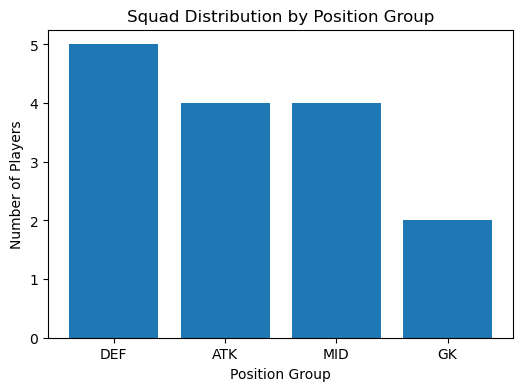

In [10]:
import matplotlib.pyplot as plt

group_counts = final_squad["Group"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(group_counts.index, group_counts.values)
plt.title("Squad Distribution by Position Group")
plt.xlabel("Position Group")
plt.ylabel("Number of Players")
plt.show()

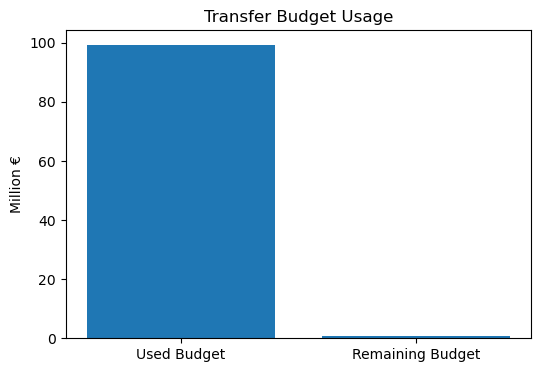

In [11]:
budget_used = final_squad["ValueM"].sum()
budget_remaining = 100 - budget_used

plt.figure(figsize=(6, 4))
plt.bar(["Used Budget", "Remaining Budget"], [budget_used, budget_remaining])
plt.title("Transfer Budget Usage")
plt.ylabel("Million €")
plt.show()

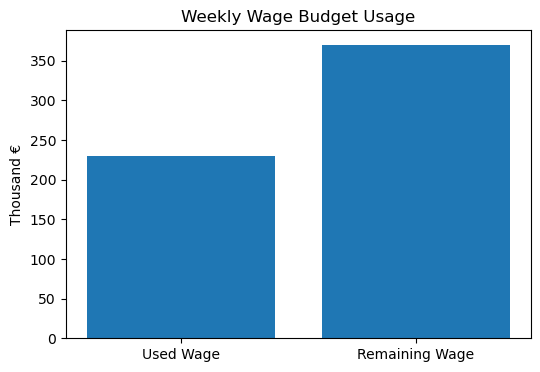

In [12]:
wage_used = final_squad["WageK"].sum()
wage_remaining = 600 - wage_used

plt.figure(figsize=(6, 4))
plt.bar(["Used Wage", "Remaining Wage"], [wage_used, wage_remaining])
plt.title("Weekly Wage Budget Usage")
plt.ylabel("Thousand €")
plt.show()

## Visualization Insights

The position distribution chart confirms that the final squad structure is balanced across the required position groups.

The transfer budget chart shows that the model uses almost the full €100M budget, which means the system actively tries to maximize squad quality under the budget constraint.

The weekly wage chart shows that the selected squad remains far below the wage limit. This indicates that the model prioritizes young and affordable players with relatively low salaries.

## Final Squad Evaluation

The final squad satisfies the main project constraints:

- The total transfer value is under the €100M budget.
- The total weekly wage is far below the €600K wage limit.
- The squad includes 15 players.
- The team structure includes Starting XI players and bench players.
- The model prioritizes young and high-potential players.

The model successfully creates a budget-constrained youth squad, but some players have low current overall ratings due to strict budget limits. This is listed as a limitation and can be improved with more advanced optimization methods.

## Strengths and Limitations

### Strengths

- Bütçe aşılmadan kadro kurulmuştur.
- Maaş limiti aşılmamıştır.
- Pozisyon dengesi korunmuştur.
- Genç ve potansiyelli oyunculara öncelik verilmiştir.
- Sistem otomatik olarak eksik pozisyonları tamamlamaktadır.

### Limitations

- Sistem gerçek transfer pazarlığı, oyuncu isteği veya kulüp prestiji gibi faktörleri hesaba katmamaktadır.
- Bazı düşük overall oyuncular bütçe kısıtı nedeniyle kadroya girebilmektedir.
- Skor sistemi rule-based olduğu için subjektif ağırlıklar içermektedir.
- Daha gelişmiş bir optimizasyon algoritması ile kalite artırılabilir.

## Future Improvements

Bu proje ileride şu şekilde geliştirilebilir:

- Daha gelişmiş optimizasyon algoritması eklenebilir.
- Her pozisyon için özel skor fonksiyonları yazılabilir.
- Oyuncuların teknik özellikleri pozisyona göre ayrı değerlendirilebilir.
- Transfer bütçesi daha akıllı dağıtılabilir.
- Takım kimyası, lig seviyesi ve kulüp prestiji gibi faktörler eklenebilir.
- Sonuçlar grafiklerle görselleştirilebilir.